## <font color='blue'> ASTR 21100</font>

## <font color='blue'> Homework Assignment 5</font>
    
 
## <font color='blue'> 35 points</font>
   
### <font color='blue'> Distributed: Thursday, February 1</font>

### <font color='blue'> Due: Thursday, February 8, 10pm</font>

<center>
<img width=300 src="https://blogs.scientificamerican.com/blogs/assets/guest-blog/File/chart.png"></img>
</center>

### <font color='blue'>Introduction</font> 

In this assignment you will implement your own ensemble sample (either DE MCMC or GW10) and will estimate dimensionless mean density of matter, $\Omega_{\rm m0}$, and dark energy, $\Omega_\Lambda$. Results of this analysis should show statistical evidence that the dark energy density is significantly different from  zero. This [dark energy](https://blogs.scientificamerican.com/guest-blog/no-astronomers-haven-t-decided-dark-energy-is-nonexistent/) has very peculiar properties (it acts as anti-gravity) and accelerates expansion of our Universe. <a href="https://www.nobelprize.org/prizes/physics/2011/press-release/">The 2011 Nobel Prize in Physics</a> was awarded for this type of analysis first published by two competing teams in 1998. 

Detailed description of the method of using supernovae type Ia to constrain the mean density of matter and dark energy in our Universe is described in [Section 9.2](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/astro.html#supernovae-type-ia-as-standardizable-candles) and [Section 9.3](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/astro.html#constraining-mean-density-of-matter-and-dark-energy-with-supernova-type-ia) of the notes notebook. Please review these sections before you work on this assignment. 

Key equations needed to implement exercises below are reproduced in this notebook. This requires a combination of the computational methods we've been discussing in the course and Bayesian statistics. Links to relevan parts of the notes describing statistical background are provided, but do reach out if something is not clear or you are not certain you understand the stat aspects of this assignment. 

There are 4 exercises described below, but you should choose exercise 2 OR 3 (i.e., implement either DE MCMC or the Goodman & Weare 2010 affine-invariant algorithm). The exercises are related because their results are combined to achieve a specific goal: to estimate the mean density of matter and dark energy in the Universe. 

A reasonable strategy for completing this assignment is to implement exercise 1 using SciPy's `differential_evolution` and exercise 4 using `emcee` package. You can then focus on exercise 2 or 3 and after you complete and test your MCMC implementation, you can redo calculations in exercise 4 with your function. 

***Note:*** If you do not complete MCMC function implementation in exercise 2 or 3, you can do exercise 4 using the [emcee]() package, which you can install following instructions [here](https://emcee.readthedocs.io/en/stable/user/install/). 

Example of how to use this package is provided below. 

***Note:*** If you are done with the exercises and want more challenge, consider optimizing MCMC functions in exercise 2 or 3 to remove the loop over members/walkers. You can also try to implement a Hamiltonian MCMC sample or explore ways to implement a parallel version of the MCMC sampler that splits work on multiple processors. If you are interested in these options for possible extra-credit, please contact instructor. 

Import NumPy and Matplotlib and set Matplotlib defaults to produce nicer plots. 

In [1]:
import numpy as np 

# use jupyter "magic" command to tell it to embed plot into the notebook 
import matplotlib.pyplot as plt
%matplotlib inline

# the following code make plots look better
def plot_prettier(dpi=150, fontsize=11, usetex=False): 
    '''
    Make plots look nicer compared to Matplotlib defaults
    Parameters: 
        dpi - int, "dots per inch" - controls resolution of PNG images that are produced
                by Matplotlib
        fontsize - int, font size to use overall
        usetex - bool, whether to use LaTeX to render fonds of axes labels 
                use False if you don't have LaTeX installed on your system
    '''
    plt.rcParams['figure.dpi']= dpi
    plt.rc("savefig", dpi=dpi)
    plt.rc('font', size=fontsize)
    plt.rc('xtick', direction='in') 
    plt.rc('ytick', direction='in')
    plt.rc('xtick.major', pad=5) 
    plt.rc('xtick.minor', pad=5)
    plt.rc('ytick.major', pad=5) 
    plt.rc('ytick.minor', pad=5)
    plt.rc('lines', dotted_pattern = [2., 2.])
    if usetex:
        plt.rc('text', usetex=usetex)
    else:
        plt.rcParams['mathtext.fontset'] = 'cm'
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plot_prettier()

### <font color='blue'>Supernova type Ia data</font> 

The code snippet below reads data from the study of <a href="https://ui.adsabs.harvard.edu/abs/2014A%26A...568A..22B/abstract">Betoule et al. (2014)</a>, which was downloaded <a href="http://supernovae.in2p3.fr/sdss_snls_jla/ReadMe.html">here</a>. The function uses numpy loadtxt function, which allows to read well formatted columns of data in the ASCII format easily. 
    
After reading numpy array <tt>zsn</tt> contains redshifts of 740 supernovae, while arrays <tt>msn</tt>, $m$, and <tt>emsn</tt> contain measured apparent magnitudes and their uncertainties. Parameters <tt>x1</tt>, <tt>ex1</tt>, <tt>csn</tt>, <tt>ecsn</tt> are the color and stretch parameters of the supernovae in their sample and their uncertainties.

In [2]:
#zsn, msn, emsn are redshift of SNia, its apparent B-band magnitude, and emB is its error
# x1 and ex1 are stretch parameter measured for each SN and its uncertainty
# csn and ecsn are color parameter and its uncertainty
zsn, msn, emsn, x1, ex1, csn, ecsn = np.loadtxt('https://astro.uchicago.edu/~andrey/classes/a211/data/jla_lcparams.txt', 
                                               usecols=(1, 4, 5, 6, 7, 8, 9), unpack=True)

print("read sample of %d supernovae..."%(np.size(zsn)))

read sample of 740 supernovae...


### <font color='blue'>Exercise 1 (8 points): Implementing posterior pdf with uniform prior pdfs and finding parameter values that maximizes likelihood of supernovae type Ia data given model parameters</font>

**Task 1a (6 points).** Implement a function to compute the natural logarithm of the posterior pdf. This is a sum of the $\ln$ of the likelihood and $\ln $ of the prior (see [Section 9.17.5](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/stat.html#bayesian-statistical-analysis)). 

The likelihood pdf of the supernova data given the model parameters using the expression derived in [Sections 9.17.14](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/stat.html#the-likelihood-pdf-of-data-given-a-model) and [Section 9.3](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/astro.html#constraining-mean-density-of-matter-and-dark-energy-with-supernova-type-ia) of the notes:

$$\ln L(\mathbf{y}\vert\mathbf{x}) = -\frac{1}{2}\,\sum\limits_{i=0}^{N_{\rm SN}-1}\frac{\Delta m_i^2}{\sigma_{\Delta m,i}^2}-\frac{1}{2}\sum\limits_{i=0}^{N_{\rm SN}-1}\ln(2\pi\sigma_{\Delta m,i}^2)$$

where $\Delta m$ is the difference between observational measurement of magnitude, $m_{\rm obs}$, and model prediction $m_{\rm pred}(z,\Omega_{\rm m0},\Omega_\Lambda)$, where $z$ is the observed redshift of the supernova $i$ then can be written as 
$$
\Delta m_i=m_{\rm i, obs} - m_{\rm pred}(z_i,\Omega_{\rm m0},\Omega_\Lambda)= m_{i, \rm obs} - 5\log_{10}d_L(z_i,\Omega_{\rm m0},\Omega_\Lambda) - M_0 +  \alpha x_{1,i} - \beta c_i - 25,$$ 

where $d_L$ is the luminosity distance, computed as in HW 3 and $x_1$ and $c$ are the "stretch" and "color" parameters measured for each supernova and are read as part of the data by the code above. You can use function `d_l_astropy` below to compute $d_L$. Note that this function will return an array of distances for an array of input redshifts. The calculation of $\Delta m$ can thus be done in one line without using the loop over supernovae.  

and $\sigma_{\Delta m,i}^2$ is total uncertainty of the observational estimate of the distance modulus that accounts for uncertainties in $m_B$, $x_1$, and $c$, which by rules of error propagation is: 

$$\sigma_{\Delta m,i}^2 = \sigma_{m_B}^2 + \alpha^2\sigma_{x1}^2 + \beta^2\sigma_c^2,$$

which means that the error also depends on the two model parameters, $\alpha$ and $\beta$. 

The vector of parameters $\mathbf{x}$ in this problem thus contains 
5 parameters $\mathbf{x}=\{\Omega_{\rm m0},\Omega_\Lambda, M_0, \alpha,\beta\}$. That is you will be solving optimization problem and sampling from the posterior pdf in 5 dimensions. 

The function should pass arrays containing supernova data  via <tt>args</tt>.

Prior pdf should be uniform for the parameters with the limits of the pdf for each model parameter as follows: $\Omega_{\rm m0}: [0,1]$, $\Omega_{\rm \Lambda}: [0,1]$, $M_0: [-25,-15]$, $\alpha: [0, 0.3]$, $\beta: [0,5]$. Feel free to experiment with these ranges. Example of how uniform prior pdf can be implemented is given for the Bayesian inference of the linear model parameters in [Section 9.17.6](https://astro.uchicago.edu/~andrey/classes/a211w24/html/appendix/stat.html#specific-example-linear-model). 

**Task 1b. (2 points)** Test your function by  finding the values of the 5 parameters $\mathbf{x}=\{\Omega_{\rm m0},\Omega_\Lambda, M_0, \alpha,\beta\}$ that minimize this function using the differential evolution function you implemented in hw 4, or <a href="https://docs.scipy.org/doc/scipy-0.15.1/reference/generated/scipy.optimize.differential_evolution.html"><tt>scipy.minimize.differential_evolution</tt></a> function. Print out the values. Note that the values of $\Omega_{\rm m0}$ and $\Omega_\Lambda$ should be close to (but not exactly equal) to the values currently determined by a combination of various observational constraints (see, e.g., last 2 lines in the Table 25.1 on p. 14 in [this paper](https://arxiv.org/pdf/2201.08666.pdf)): $\Omega_{\rm m0}\approx 0.3$ and $\Omega_\Lambda\approx 0.7$. 



**Task 1c (2 points)** Modify the $\chi^2$ function from ex 4 of hw 4 to account for the different calculation of $m_{\rm pred}$ and calculate and print the reduced $\chi^2$ value for the best fit model obtained in 1b. Remember that the number of parameters in this model is $N_{\rm param}=5$. 

$$\chi^2_{\rm red} = \frac{1}{N_{\rm SN}-N_{\rm param}}\sum\limits_{i=0}^{N_{\rm SN}-1}\frac{ (m_{i,\rm obs}-m_{\rm i,\rm pred})^2}{\sigma_{\Delta m_i}^2},$$

where

$$
\Delta m=m_{\rm obs} - m_{\rm pred} =m_{\rm obs} - M_0 - 5\log_{10}d_L(z,\Omega_{\rm m0},\Omega_\Lambda)+  \alpha x_1 - \beta c - 25.
$$

and 
$$\sigma_{\Delta m,i}^2 = \sigma_{m_B}^2 + \alpha^2\sigma_{x1}^2 + \beta^2\sigma_c^2,$$


In [13]:
from astropy.cosmology import LambdaCDM
import astropy.units as u

def minimize_de(func, x0, *args, atol = 1e-8, s = 0.1, bounds = None):
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    for dim in range(ndim):
        xmin = bounds[dim][0]
        xmax = bounds[dim][1]
        for i in range(npop):
            x0[i,dim] = xmin + (xmax-xmin)*np.random.uniform(0,1)
    xnow = np.copy(x0)
    fnow = np.array([func(x, *args) for x in x0])
    xnext = np.zeros_like(x0)
    while True:
        for i in range(npop):
            inds = np.arange(0,npop)
            inds = np.delete(inds,i)
            np.random.shuffle(inds)
            ir1, ir2, ir3 = inds[:3]     
            scale_factor = np.random.uniform(s, 1)
            xtry = xnow[ir3] + scale_factor * (xnow[ir1] - xnow[ir2])
            xtry = np.clip(xtry, bounds[:, 0], bounds[:, 1])
            ftry = func(xtry, *args)
            if ftry <= fnow[i]:
                xnext[i] = xtry
                fnow[i] = ftry
            else:
                xnext[i] = xnow[i]
        if np.max(np.abs(xnext - xnow)) < atol:
            break
        xnow = np.copy(xnext) 
    best_index = np.argmax(fnow)
    return xnow[best_index],fnow[best_index]

def d_l_astropy(z, H0, Om0, OmL, clight=2.99792e5):
    cosmo = LambdaCDM(H0 = H0, Om0=Om0, Ode0=OmL)   
    return cosmo.luminosity_distance(z=z) / u.Mpc 

def m_pred(z, x, c, M0, Om, Ol, Al, Be):
    dL = d_l_astropy(z, 70, Om, Ol)
    return 5 * np.log10(dL) + 25 + M0 + Be*c - Al*x

## Task 1a
def ln_pdf(params,*args):
    M0, Om, Ol, Al, Be = params
    zsn = args[0] 
    msn = args[1] 
    emsn = args[2]
    x1 = args[3] 
    ex1 = args[4]
    csn = args[5] 
    ecsn = args[6]
    unc = emsn**2 + (Al**2 * ex1**2) + (Be**2 * ecsn**2)
    m_predicted = m_pred(zsn, x1, csn, M0, Om, Ol, Al, Be)
    chi2 = -0.5 *np.sum((msn - m_predicted)**2 / unc)
    chi  = -0.5 *np.sum(np.log(2 * np.pi * unc))
    return chi2 + chi

In [ ]:
## Part 1b
H0 = 70
npop = 60
x0 = np.random.rand(npop, 5)
# Bounds for parameters
# 𝑀0:[−25,−15], Ωm0:[0,1], ΩΛ:[0,1], 𝛼:[0,0.3], 𝛽:[0,5]  #
param_bounds = np.array([(-25, -15), (0, 1), (0, 1), (0, 0.3), (0, 5)])
args = [zsn, msn, emsn, x1, ex1, csn, ecsn]
# Minimization using minimize_de
result = minimize_de(ln_pdf, x0, *args, s = 0.1, bounds = param_bounds)
# Best-fit parameters and minimum chi-square
best_fit_params = result[0]

print("Best-fit Parameters:")
print("M0:", best_fit_params[0])
print("Om:", best_fit_params[1])
print("Ol:", best_fit_params[2])
print("𝛼:", best_fit_params[3])
print("𝛽:", best_fit_params[4])


In [6]:
## Part 1c
def chi_square(params, *args):
    M0, Om, Ol, Al, Be = params
    zsn = args[0] 
    msn = args[1] 
    emsn = args[2]
    x1 = args[3] 
    ex1 = args[4]
    csn = args[5] 
    ecsn = args[6]
    unc = emsn**2 + (Al*ex1)**2 + (Be*ecsn)**2
    m_predicted = m_pred(zsn,x1,csn, M0, Om, Ol,Al,Be)
    chi2 = -0.5*np.sum((msn - m_predicted)**2 / unc)
    reduced_chi2 = chi2 / (len(zsn) - len(params))
    return reduced_chi2
print(chi_square(best_fit_params, *args))

-1524.7041207245509


### <font color='blue'> Exercise 2: Implementing the Differential evolution MCMC algorithm  (15 points). </blue>
    
#### <font color='blue'>Task 2a (12 points).</blue>
Implement the Differential Evolution MCMC algorithm proposed by Ter Braak (2006) and described in [Section 7.5.14](https://astro.uchicago.edu/~andrey/classes/a211w24/html/mc/mcmc.html#differential-evolution-mcmc-de-mcmc) of the notes  in a Python function.
    
The overall structure of the function is similar to the differential evolution function you should have implemented in hw 4 and you can use your implementation or implementation in the solution that will be provided to you as a starting point. The difference is in the way that steps (mutation) are made and condition defining whether a step is accepted or rejected are different. The stopping criterion here, however, can be simple - for example, stop after a given number of steps is made. 
    

Below is the possible format of such function. 
    
    
    def mcmc_de(x0, logpdf = None, args = None, nsteps=10000):
        """
        MCMC sampler implementing the Goodman & Weare (2010) 
        affine-invariant algorithm 

        run for nminsteps and convergence specified by convergence_func is reached

        Parameters:
        ------------
        x - numpy array of floats of shape (nwalkers,ndim)
            containing initial x values of the chains
        logpdf - python function object
            ln(pdf) where pdf is the target pdf to sample
        args - tuple with arguments to pass logpdf functions (as logpdf(x, *args))
        nteps - int
            minimum number of MCMC steps (iterations) to make
    
        Returns:
        ---------
        chain - numpy array of shape (nwalkers*nsteps, ndim)
            x values of samples in the MCMC chains given that chain length is nsteps
        """


***Note:*** After you implement and test your version and complete the exercises, you can try to use numpy capabilities to optimize
the MCMC function so that there is only the loop making steps and there are no loops over walkers and dimensions. Feel free to ask for guidance. 

    
***Note:*** It can be convenient to define a class that implements MCMC sampler and methods associated with it (this is what is done in the <tt>emcee</tt> package). Once you are done with your function and the rest of the homework, I encourage you try this if you want to practice using classes in practice. Feel free to ask for guidance. 


#### <font color='blue'> Task 2b (3 points)</font>

Test your implementation of the DE MCMC algorithm by sampling $\ln$ 2d Gaussian pdf using function <tt>lngauss_nd</tt> below. Plot resulting distributions of chain values for $\Omega_{\rm m0}$ and $\Omega_\Lambda$ along with the confidence contours that correspond to $1-$ and $2-\sigma$ of the Gaussian distribution and enclose $0.6827$ and $0.9545$ of the total samples using example below using <tt>plot_2d_dist</tt> function from <tt>codes/plotting.py</tt>. 

Example below shows such test using <tt>emcee</tt> package. 

In [12]:
def lngauss_nd(x, means, icov):
    diff = x - means  
    return -0.5 * np.dot(diff.T, np.dot(icov,diff)) 
def mcmc_de(x0, b, d, logpdf=None, args=None, nsteps=10000,bounds = None):
    gamma = 2.38 / np.sqrt(d)
    ndim = np.shape(x0)[1]
    npop = np.shape(x0)[0]
    xnow = np.copy(x0)
    fnow = np.array([logpdf(x, *args) for x in x0])
    xchain = np.zeros((nsteps, npop, ndim))  # Store all parameter samples
    fchain = np.zeros((nsteps, npop))
    for ii in range(nsteps):
        for i in range(npop):
            inds = np.arange(0, npop)
            inds = np.delete(inds, i)
            np.random.shuffle(inds)
            ir1, ir2 = inds[:2]
            ee = np.random.uniform(-b, b)
            xtry = xnow[i] + gamma * (xnow[ir1] - xnow[ir2]) + ee
            if bounds is not None:
                xtry = np.clip(xtry, bounds[:, 0], bounds[:, 1])
            ftry = logpdf(xtry, *args)
            f1 = logpdf(xnow[i], *args)
            u = np.log(np.random.uniform(0, 1))
            if u <= ftry - f1:
                xnow[i] = xtry
                fnow[i] = ftry
        # Store the samples at each step
        xchain[ii] = xnow
        fchain[ii] = fnow

    # Return the last sample as the best-fit parameters
    best_index = np.argmax(fnow)
    return xnow[best_index], fnow[best_index], xchain, fchain


acceptance fraction = 0.235


C:\Users\barre\ASTR 211 Winter\codes\plotting.py:344: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contour(X, Y, H, linewidths=(1.0,0.75, 0.5, 0.25), colors='black', levels = sorted(lvls),


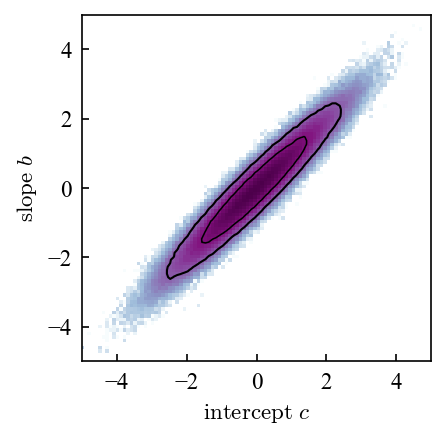

In [8]:
from codes.plotting import plot_2d_dist
# define st deviations for the two dimension of the Gaussian and value of correlation coefficient
means = [0., 0.] # values of means of Gaussian pdf for 2 dimensions
s1, s2, r = 1.0, 1.0, 0.95

# covariance matrix of 2-dimensional Gaussian
cov = [[s1**2, r*s1*s2], [r*s1*s2, s2**2]]
# compute the inverse covariance matrix
icov = np.linalg.inv(cov)
args = [means, icov]
ndim, nwalkers, nsteps = 2, 50, 50000
# initialize walkers around best fit parameter values
p0 = 0.05 * np.random.normal(size=(nwalkers,ndim))
# run for a given nsteps
dummy = mcmc_de(p0, 0.1 ,2,logpdf = lngauss_nd, args = args, nsteps = nsteps)
chain = dummy[2]
conflevs = [0.6827, 0.9545]

x = chain[:,:,0].flatten()
y = chain[:,:,1].flatten()
facc = np.unique(chain[:,:,0].flatten()).size / np.size(chain[:,:,0].flatten())
print(f'acceptance fraction = {facc:.3f}')

plot_2d_dist(x, y, xlim=[-5, 5], ylim =[-5,5], 
             nxbins=100, nybins=100, 
             clevs=conflevs, 
             xlabel=r'${\rm intercept}\ c$', 
             ylabel=r'${\rm slope}\ b$', figsize=(3,3))

Compute mean, median and their credible (aka confidence) regions. 

In [9]:
def clims(a):
    x1 = 0.5*(100.-a)
    return x1, a + x1

def chain_stats(x, param_name='x'):
    xmed = np.median(x); xm = np.mean(x); xsd = np.std(x)
    a = 68.268; 
    x1, x2 = clims(a)
    xcfl11 = np.percentile(x,x1); xcfl12 = np.percentile(x,x2)
    a = 95.452
    x1, x2 = clims(a)
    xcfl21 = np.percentile(x,x1); xcfl22 = np.percentile(x,x2)
    dashedline = '-------'
    print('============ statistics for the {:s} ============'.format(param_name))
    print('mean, median = %.3f, %.3f, st.dev=%.4f'%(xm, xmed, xsd))
    print('68 perc interval = %.3f, %.3f'%(xcfl11, xcfl12))
    print('95 perc interval = %.3f, %.3f'%(xcfl21, xcfl22))


In [10]:
chain_stats(chain[:,0], param_name='x')
chain_stats(chain[:,1], param_name='y')

============ statistics for the x ============
mean, median = -0.025, -0.037, st.dev=0.9964
68 perc interval = -1.015, 0.983
95 perc interval = -2.015, 1.956
============ statistics for the y ============
mean, median = -0.023, -0.020, st.dev=1.0032
68 perc interval = -1.033, 0.959
95 perc interval = -2.016, 2.000


Note that we estimate mean for the parameters with uncertainty $0.07-0.09$ despite the fact that we have 50000 samples because effective number of independent samples here is only a few thousand due to correlations between neighboring samples. 

### <font color='blue'> Exercise 4: using DE MCMC or GW 10 MCMC  to sample the likelihood (10 points). </font>

Use a function that defines the natural logarithm of the posterior pdf with uniform priors implemented in exercise 1 for all parameters $\ln p$ to generate as many samples of the posterior pdf as you can using the DE MCMC or GW 10 method you implemented in exercise 2 or 3. 

* Initialize positions of the member/walkers as to avoid burn-in in the MCMC sequence (hint: use results obtained in exercise 1). (1 point)

* Run MCMC sampling of the log of the posterior pdf implemented in exercise 1 to produce MCMC chains for all 5 model parameters. You can produce few thousand samples while you are testing, but present your final results with at least 10000 samples for your final statistical results below (5 points). 

* Make trace plots for every parameters and visually estimate the correlation time as the typical widths of peaks and valleys in the trace plot. Estimate (roughly) the number of independent samples in your chain and the fractional accuracy of the statistical measurements you can expect from the chains. (3 points)

* Plot resulting distributions of chain values for $\Omega_{\rm m0}$ and $\Omega_\Lambda$ along with the confidence contours that correspond to $1-$ and $2-\sigma$ similarly to the example of the Gaussian distribution and enclose $0.6827$ and $0.9545$ in exercise 3b above. Use examples above  (for example, function <tt>chain_stats</tt> to output statistics about $\Omega_{\rm m0}$ and $\Omega_\Lambda$) to output statistics of these quantities. (1 point)

***Note:*** If you don't manage to complete your implementation of DE MCMC or GW10, you can use <tt>emcee</tt> package, using example shown above, to complete this exercise. 

***Note:*** Instead or in addition to plotting $\Omega_{\rm m0}$ and $\Omega_\Lambda$ using `plot_2d_dist` you can plot posterior distributions for all parameters using the [corner package](https://corner.readthedocs.io/en/latest/). 

In [11]:
args = [zsn, msn, emsn, x1, ex1, csn, ecsn]
ndim, nwalkers, nsteps = 5, 50, 10000
param_bounds = np.array([(-25, -15), (0, 1), (0, 1), (0,0.3), (0,5)])
initial_positions = np.array([(best_fit_params * np.random.uniform(0,0.03) ) for _ in range(nwalkers)])

result_mcmc = mcmc_de(initial_positions, b = 0.1, d = 5, logpdf = ln_pdf, args = args, nsteps = nsteps, bounds = param_bounds)
best_fit_params_mcmc = result_mcmc[0]

# Extract chains from the MCMC result
xchain_mcmc = result_mcmc[2]
# Plot trace plots for each parameter
fig, axes = plt.subplots(5, 1, figsize=(8, 10), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(xchain_mcmc[:, :, i], alpha=0.5)
    ax.set_ylabel(f'Parameter {i+1}')
plt.xlabel('Step')
plt.show()
# Extract chains for Omega_m0 and Omega_Lambda
omega_m0_chain = xchain_mcmc[:, :, 1].flatten()
omega_lambda_chain = xchain_mcmc[:, :, 2].flatten()
# Plot the 2D distribution with confidence contours
plot_2d_dist(omega_m0_chain, omega_lambda_chain, xlim=[0, 1], ylim=[0, 1],
             nxbins=100, nybins=100, clevs=[0.6827, 0.9545],
             xlabel=r'$\Omega_{m0}$', ylabel=r'$\Omega_{\Lambda}$', figsize=(6, 6))


KeyboardInterrupt: 